<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**
La diferencia principal es qué información se quiere observar de la misma señal.
En el dominio del tiempo, se ve cómo la señal cambia con el paso del tiempo, por ejemplo, sus picos y variaciones.
En el dominio de la frecuencia, vemos qué frecuencias componen la señal y con qué amplitud aparecen.
Esto permite identificar si existen ruidos o componentes de ciertas frecuencias que no son fáciles de observar en el tiempo.


In [23]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 16
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [17]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


In [24]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [26]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [28]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 45
Anotaciones del registro 16272: 30
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [6]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

**1. ¿Cuál es la frecuencia de muestreo de cada registro?**

* Registro 16265: **128 Hz**
* Registro 16272: **128 Hz**
* Registro 16420: **128 Hz**

**2. ¿Los tres registros tienen la misma frecuencia de muestreo?**

Sí. Los tres registros tienen la misma frecuencia de muestreo: **128 Hz**.

**3. ¿Cuántos canales posee cada registro?**

Cada registro posee **2 canales: ECG1 y ECG2**.

**4. ¿Qué señal corresponde al canal `0`?**

El canal `0` corresponde a la señal **ECG1**, que representa una señal de electrocardiograma.

**5. ¿Cuántas muestras contiene cada registro?**

Cada registro contiene **3600 muestras**.

**6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?**

Porque `fs = 360 Hz` significa que se toman **360 muestras por segundo**.  
Por lo tanto:

`3600 / 360 = 10 segundos`

Así, 3600 muestras representan aproximadamente **10 segundos de señal**.


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [7]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


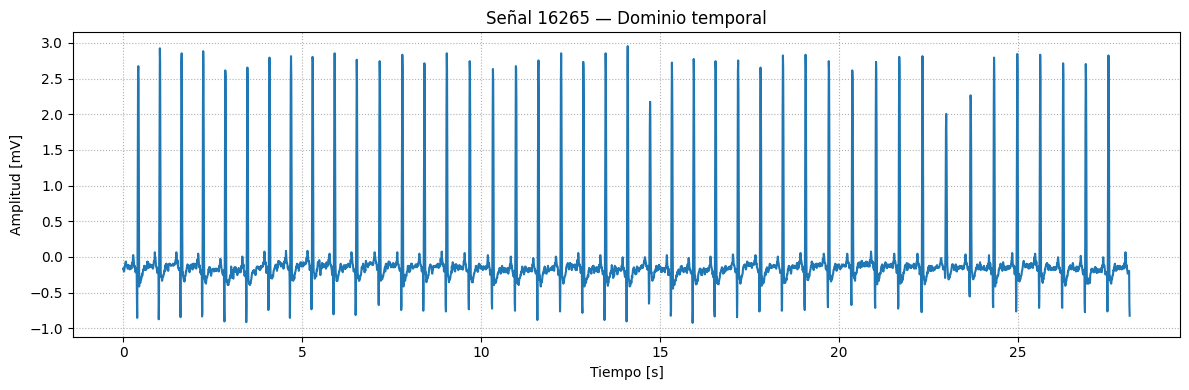

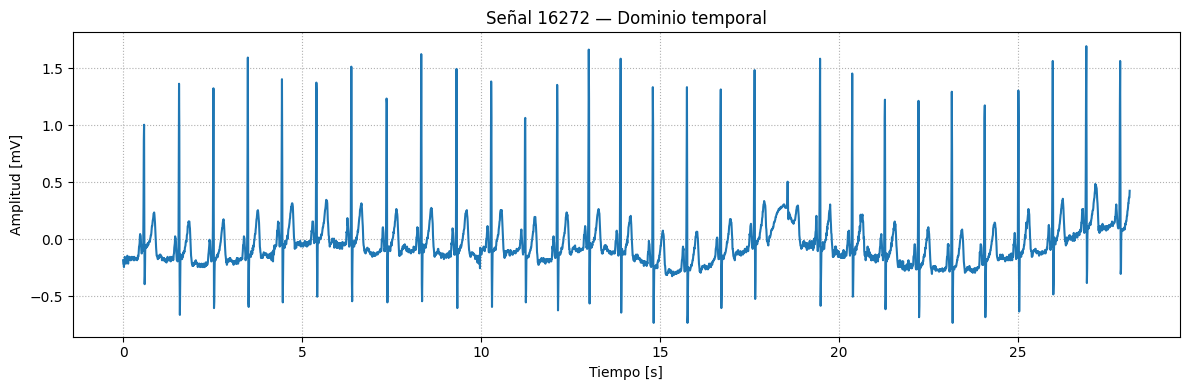

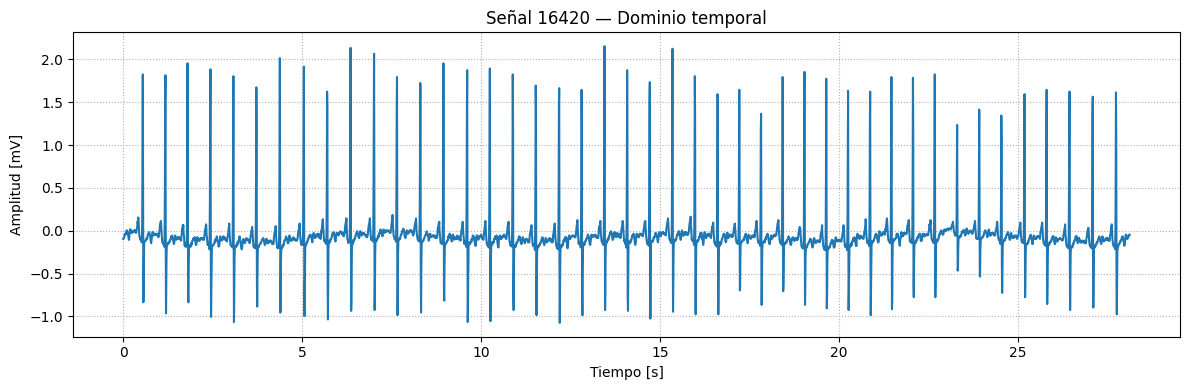

In [8]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?
*   Sí. Las tres presentan un patrón parecido de ECG, con picos altos y cambios repetitivos. Sin embargo, la forma y amplitud de los picos varían entre registros.
2. ¿Cuál presenta mayor variación de amplitud?
*La señal 16265 presenta una mayor variación de amplitud, ya que sus picos alcanzan valores más altos y también presenta cambios marcados hacia valores negativos.
3. ¿Se observan patrones periódicos?
*Sí. Se observan picos que se repiten aproximadamente a intervalos regulares, correspondientes a los latidos del corazón.
4. ¿Se identifican eventos o cambios particulares?
*Sí. Se observan algunos cambios en la amplitud y en la forma de los picos, especialmente en ciertos momentos de las señales. Estos cambios pueden representar variaciones en los latidos o características particulares del registro.
5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?
*Podemos observar cómo cambia la señal con el tiempo, identificar los picos, estimar la regularidad de los latidos y reconocer cambios o alteraciones visibles en la señal.

# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [9]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [10]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


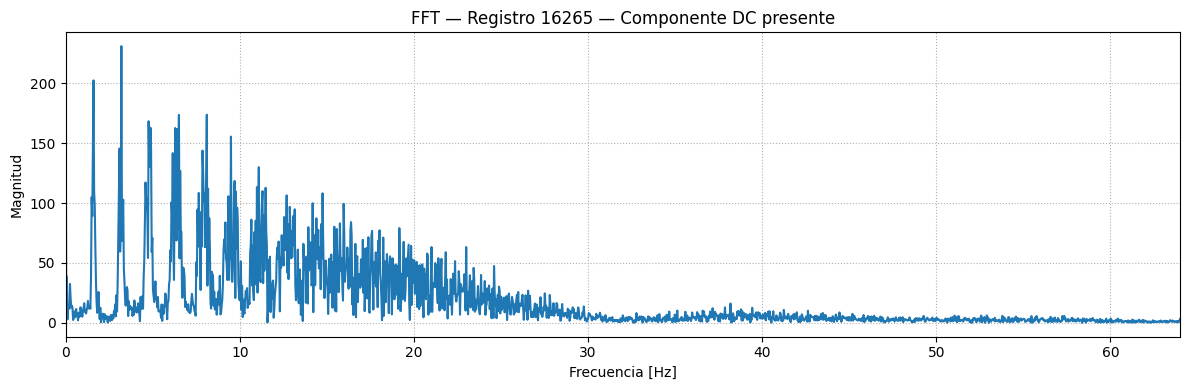

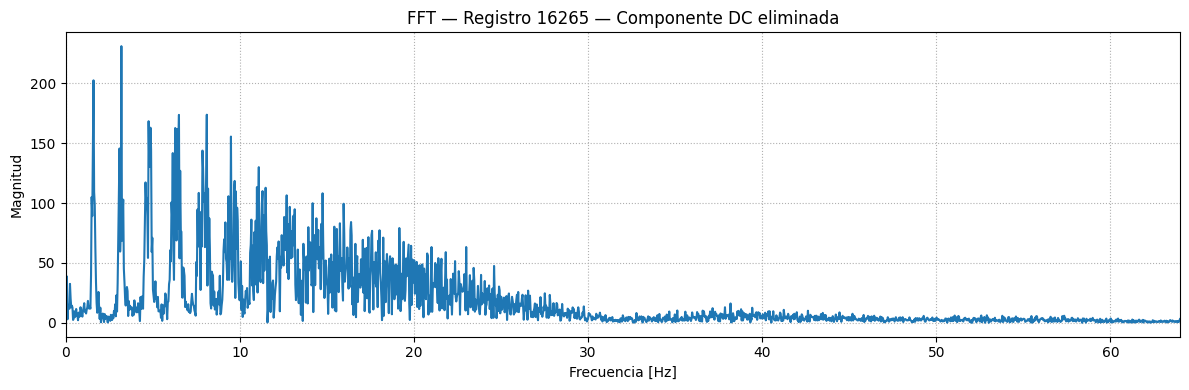

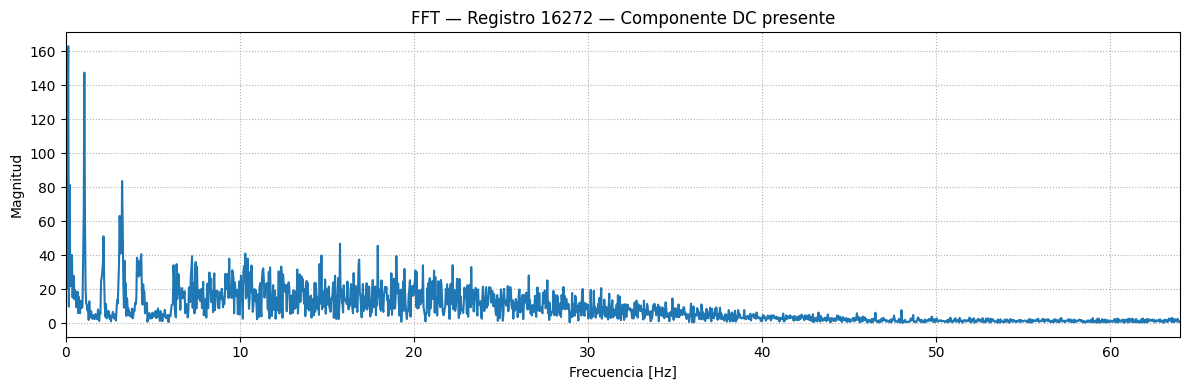

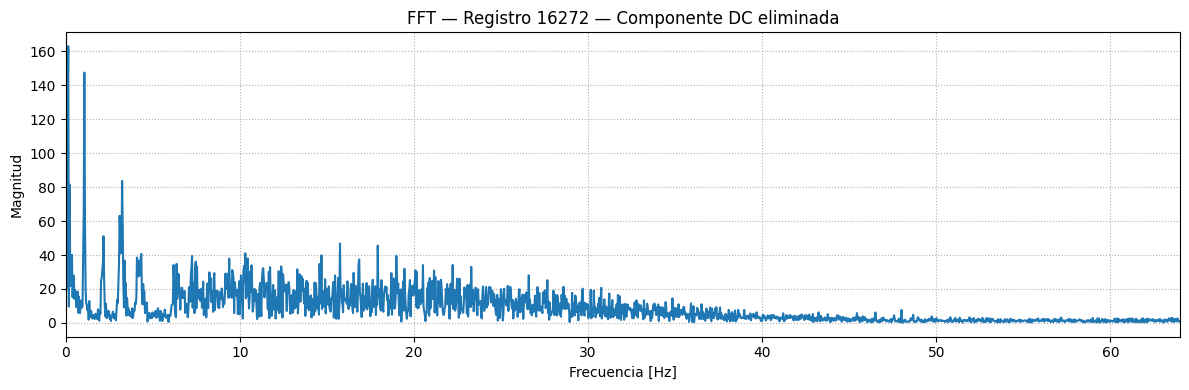

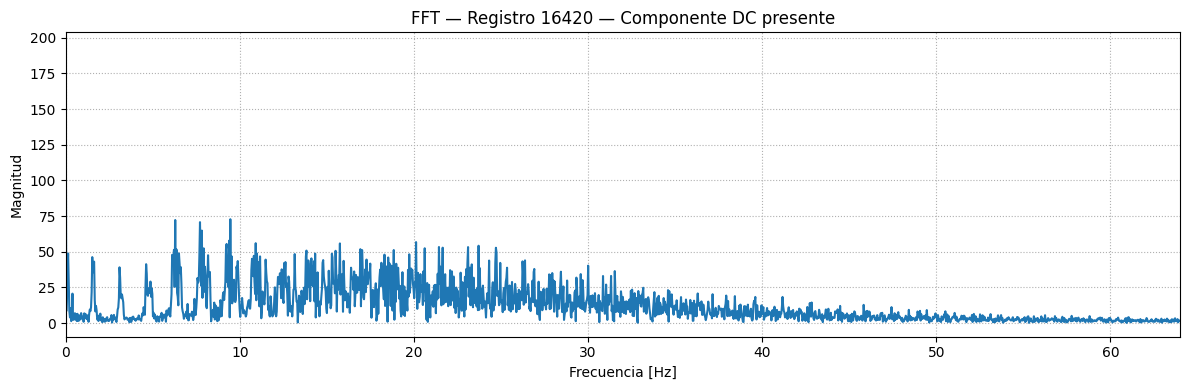

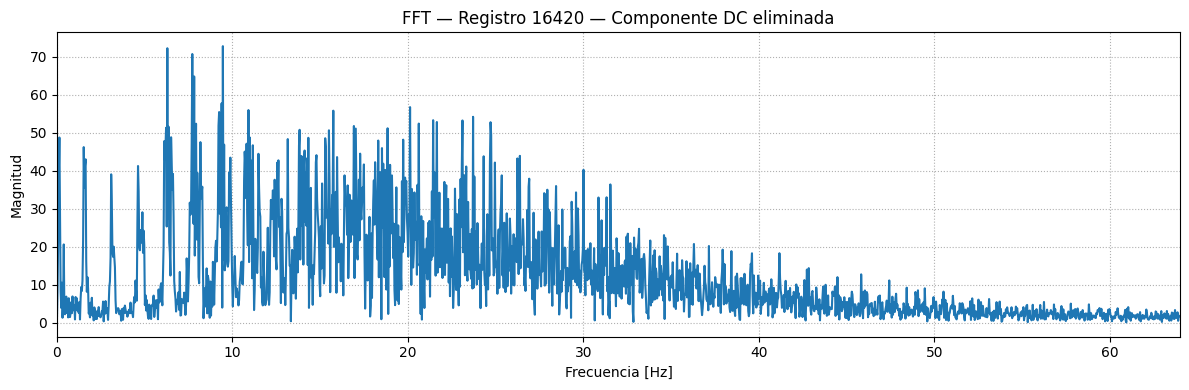

In [11]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?
* Al eliminar la media de la señal, se elimina su componente DC, por lo que el pico cercano a 0 Hz disminuye o desaparece. Esto permite observar mejor las componentes variables de la señal.
2. ¿Qué diferencias observa entre los espectros de los tres registros?
* Los tres registros tienen espectros diferentes en amplitud y distribución de frecuencias. El 16265 presenta picos de mayor magnitud, mientras que el 16272 tiene magnitudes menores. El 16420 presenta la energía más distribuida en varias frecuencias.
3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?
* La mayor parte de la energía se concentra principalmente en las frecuencias bajas, aproximadamente entre 0 y 30 Hz, donde se observan los picos más importantes.
4. ¿Por qué la FFT no conserva directamente la información temporal?
* Porque la FFT transforma la señal del dominio del tiempo al dominio de la frecuencia. Por ello, muestra qué frecuencias están presentes, pero no indica directamente en qué momento ocurrió cada evento.
5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?
* Permite identificar fácilmente qué frecuencias predominan en la señal, además de detectar componentes, ruido o cambios que pueden ser difíciles de observar directamente en la gráfica temporal.


# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [12]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 3.200 Hz, magnitud = 230.841
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096
Registro 16420: frecuencia dominante = 9.458 Hz, magnitud = 72.800


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [13]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [14]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


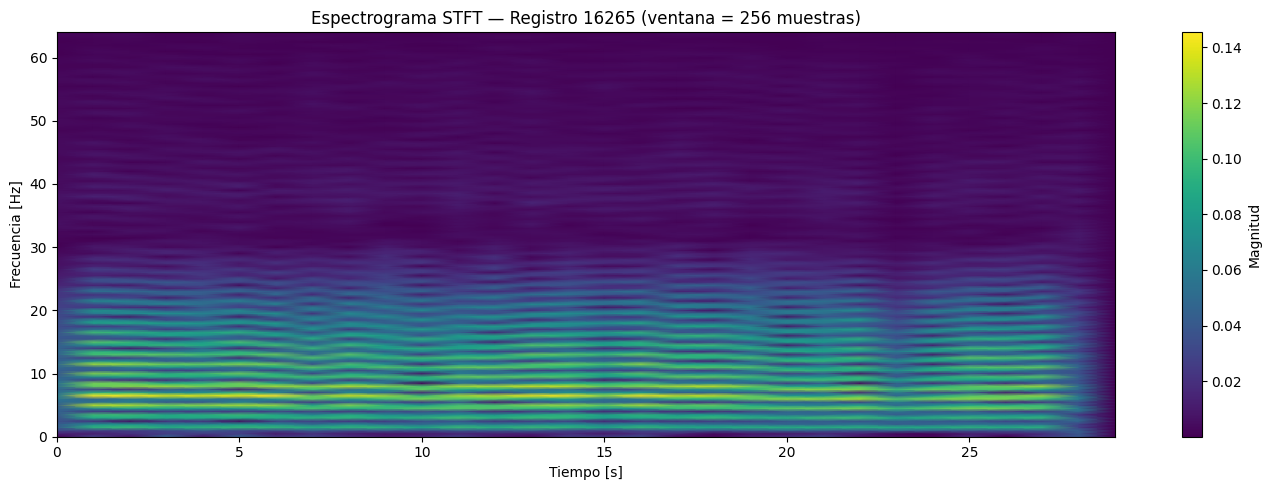

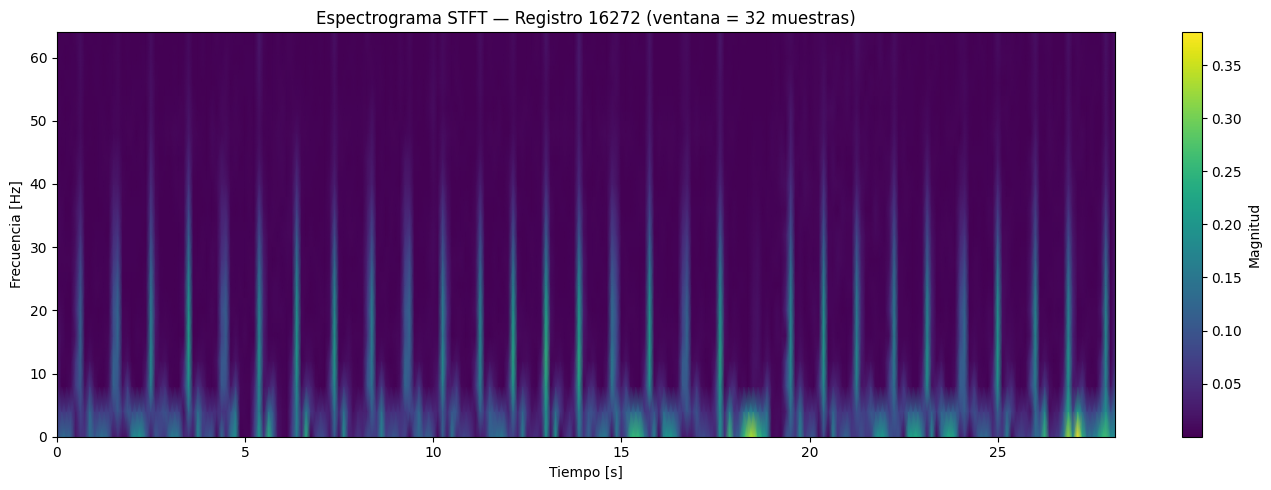

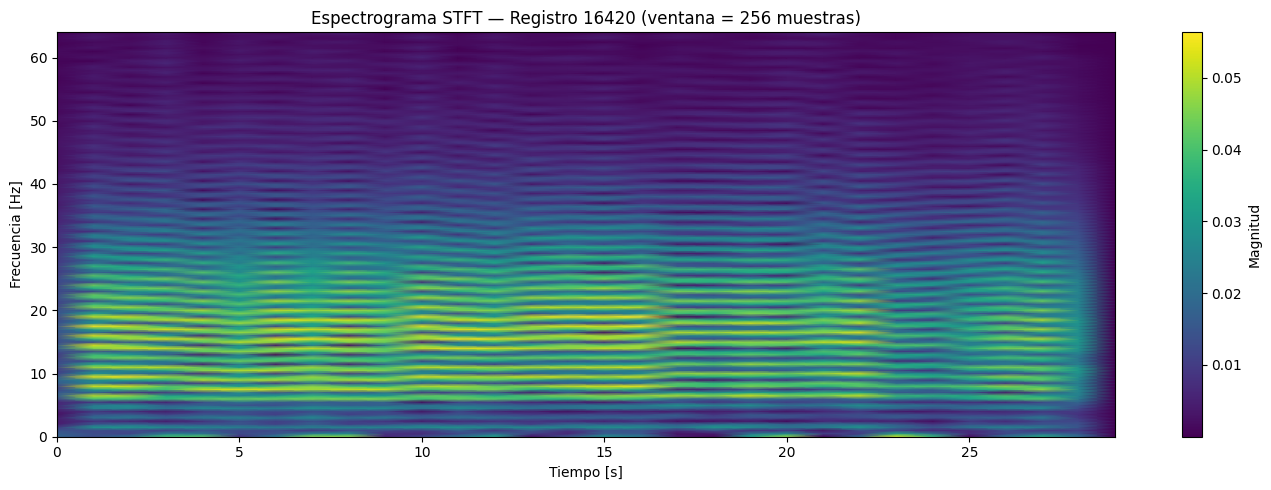

In [15]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?
* La STFT permite observar cómo cambian las frecuencias de la señal a lo largo del tiempo. A diferencia de la FFT, que muestra las frecuencias de toda la señal en conjunto, la STFT permite saber en qué momento aparecen o cambian ciertas frecuencias.
2. ¿En qué momentos se observan cambios de energía?
* Se observan cambios de energía en diferentes momentos a lo largo de los registros. En el 16272, por ejemplo, aparecen zonas de mayor intensidad principalmente en las frecuencias bajas y en algunos instantes cercanos al final del registro.
3. ¿Qué diferencias observa entre los tres espectrogramas?
* Los tres presentan diferencias en la distribución e intensidad de la energía. Algunos concentran más energía en frecuencias bajas, mientras que otros presentan componentes distribuidas en un rango mayor de frecuencias. También cambia la intensidad a lo largo del tiempo.
4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?
* Se utiliza una ventana más pequeña para obtener una mejor resolución temporal, es decir, para poder detectar cambios rápidos en la señal. Como fs = 128 Hz, 32 muestras representan aproximadamente 0.25 segundos de señal.
5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?
* Se obtiene una mejor resolución en frecuencia, pero se pierde resolución temporal. Esto significa que podemos distinguir mejor las frecuencias, pero será más difícil saber exactamente cuándo ocurre un cambio.
6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?
* Se obtiene una mejor resolución temporal, pero peor resolución en frecuencia. Es decir, podemos detectar mejor cuándo ocurre un evento, pero será más difícil distinguir entre frecuencias cercanas.


# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo |128 | 128|128 |
| Número de muestras |3600 | 3600| 3600|
| Número de canales | 2|2 |2 |
| Amplitud observada | Mayor variación, aprox. -0.9 a 3.0 mV| Menor amplitud, aprox. -0.7 a 1.7 mV|Variación intermedia, aprox. -1.1 a 2.2 mV |
| Componente DC |Hay componente Dc |Hay componente Dc  |Hay componente Dc  |
| Frecuencias dominantes |3.200 Hz |0.142 Hz |9.458 Hz |
| Comportamiento STFT | Energía principalmente en bajas frecuencias|Cambios rápidos de energía; ventana de 32 muestras | Energía distribuida principalmente en bajas frecuencias|
| Observaciones |Presenta picos de mayor amplitud |Presenta menor amplitud y variaciones en el tiempo | Presenta energía más distribuida y cambios en diferentes frecuencias|

### Discusión

Explique:

- qué registro presenta mayor variabilidad;
* El registro 16265 presenta la mayor variación de amplitud, ya que sus picos alcanzan valores más altos y presenta cambios importantes durante el registro.
- qué diferencias aparecen en el dominio temporal;
* Los tres registros tienen un patrón similar de ECG, pero cambian la amplitud, la forma de los picos y la regularidad. El 16265 presenta picos más altos, mientras que el 16272 presenta amplitudes menores.
- qué diferencias aparecen en el dominio frecuencial;
* Los registros tienen diferentes frecuencias dominantes: 3.200 Hz en 16265, 0.142 Hz en 16272 y 9.458 Hz en 16420. Esto muestra que cada señal distribuye su energía de manera diferente entre las frecuencias.
- qué información adicional aporta la STFT;
* La STFT permite saber cómo cambia la energía de las diferentes frecuencias a lo largo del tiempo. Por eso, además de saber qué frecuencias existen, podemos identificar en qué momentos aparecen cambios en ellas.
- cómo influye el tamaño de ventana.
* Una ventana pequeña, como las 32 muestras usadas en 16272, permite detectar mejor cambios rápidos en el tiempo, pero distingue peor las frecuencias. Una ventana grande, como 256 muestras, permite una mejor resolución en frecuencia, pero pierde precisión para localizar cambios rápidos en el tiempo.

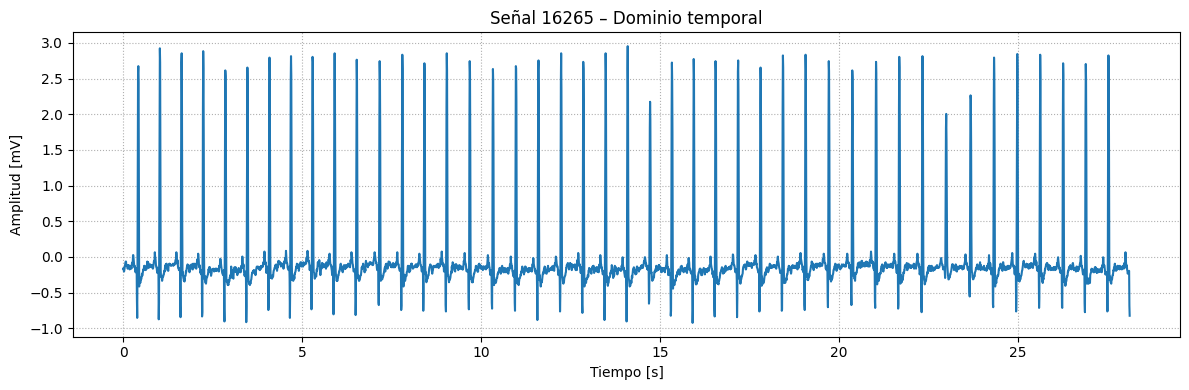

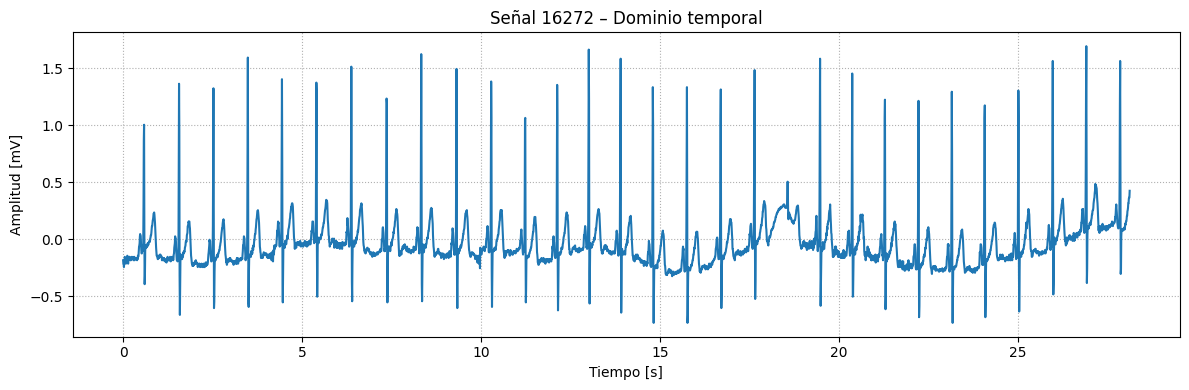

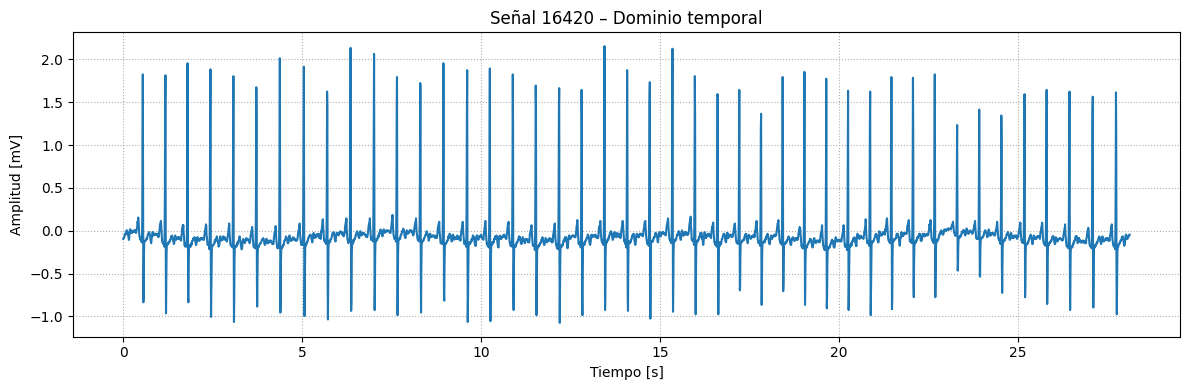

In [32]:
# ejercicio propuesto 2.1
for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} – Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

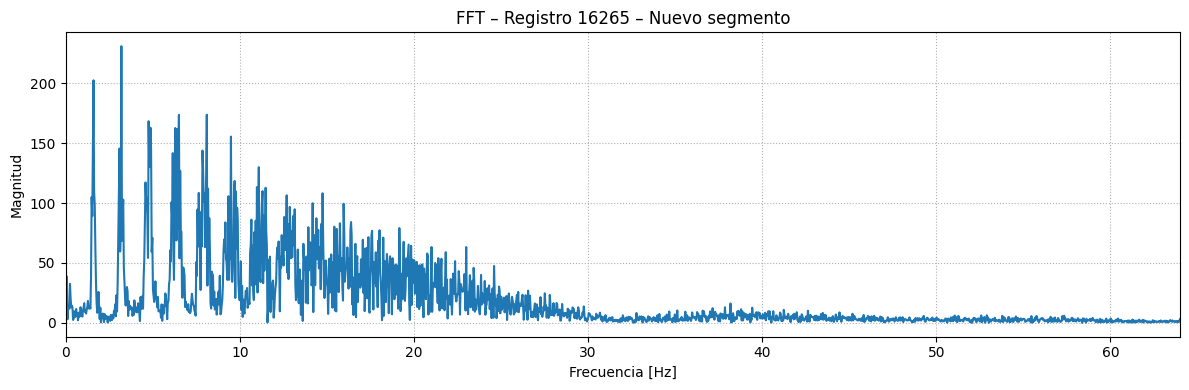

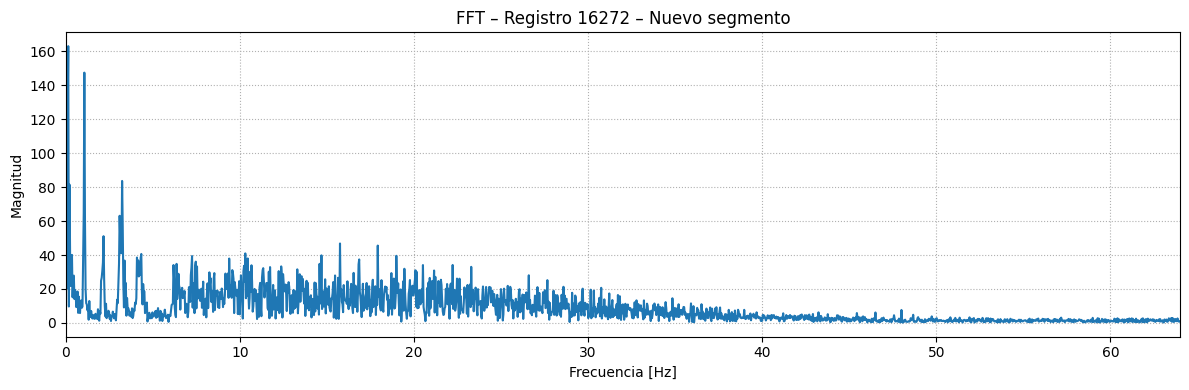

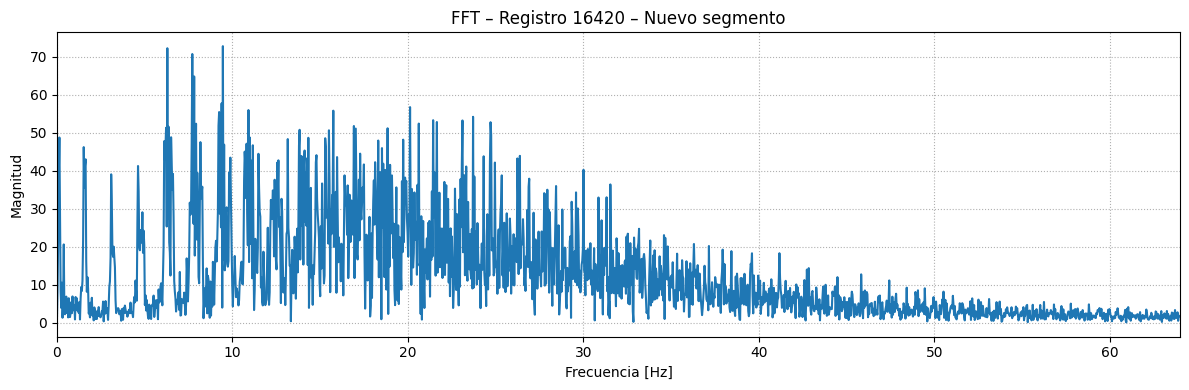

In [33]:
fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(x, fs)

    fft_data[record_name] = {
        "frecuencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }
# ============================================
# ESPECTRO FFT - NUEVO SEGMENTO
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(data["frecuencies"], data["magnitude_ac"])

    plt.title(f"FFT – Registro {record_name} – Nuevo segmento")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, data["frecuencies"][-1])
    plt.grid(True, linestyle=":")

    plt.tight_layout()
    plt.show()

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal
Modifique:

```python
SAMPFROM = 0
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

1. ¿La morfología cambia?
* La morfología se mantiene bastante similar, ya que las tres señales siguen mostrando los mismos patrones característicos del ECG. Sin embargo, cambian ligeramente la amplitud y la forma de algunos picos.
2. ¿El espectro cambia?
* Sí. El espectro presenta pequeñas variaciones en la amplitud y distribución de las frecuencias, aunque mantiene características similares al segmento original.
3. ¿La STFT muestra nuevos eventos?
* Sí, al analizar otro segmento pueden observarse cambios de energía en diferentes momentos y frecuencias. La STFT permite identificar dónde ocurren esos cambios a lo largo del tiempo.
4. ¿Qué diferencias encuentra respecto al segmento original?
* Las diferencias son principalmente pequeñas variaciones en la amplitud, los picos y la distribución de energía. El comportamiento general de las señales se mantiene, porque seguimos analizando registros ECG similares.
---

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```

### Responda

1. ¿Cuál permite observar mejor los eventos temporales?
* La ventana de 32 muestras, porque se observan cambios más definidos a lo largo del tiempo y permite localizar mejor cuándo ocurren los eventos.
2. ¿Cuál proporciona mayor detalle en frecuencia?
* La ventana de **256 muestras**, porque permite distinguir mejor las diferentes componentes de frecuencia.

3. ¿Cuál considera más apropiada para este registro? Justifique.
* La ventana de **32 muestras** es la más apropiada para este registro, porque permite observar con mayor claridad los cambios y eventos temporales de la señal. Aunque la ventana de 256 muestras tiene mayor detalle en frecuencia, pierde precisión temporal.
---

## Ejercicio 2.3 — Comparación FFT vs. STFT

Explique con sus propias palabras:

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?
* Una FFT global analiza toda la señal de una sola vez mostrando las frecuencias pero no en que momento aparecen estas frecuencias. Por otro lado, las STFT divide la señal en partes o ventanas y calcula el espectro de cada una de ellas para permitir ver cuándo las frecuencias cambian.



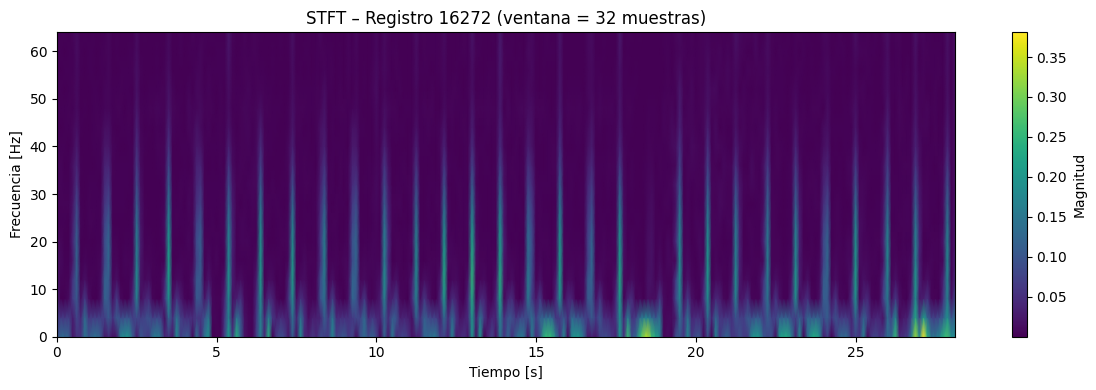

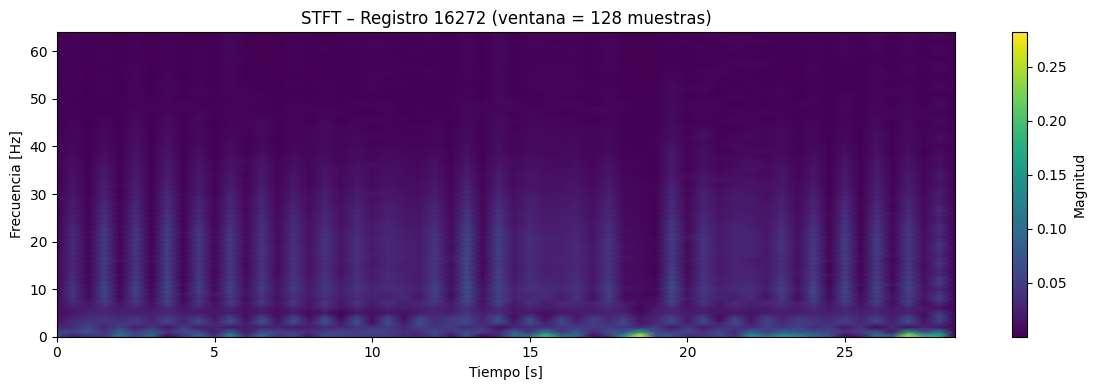

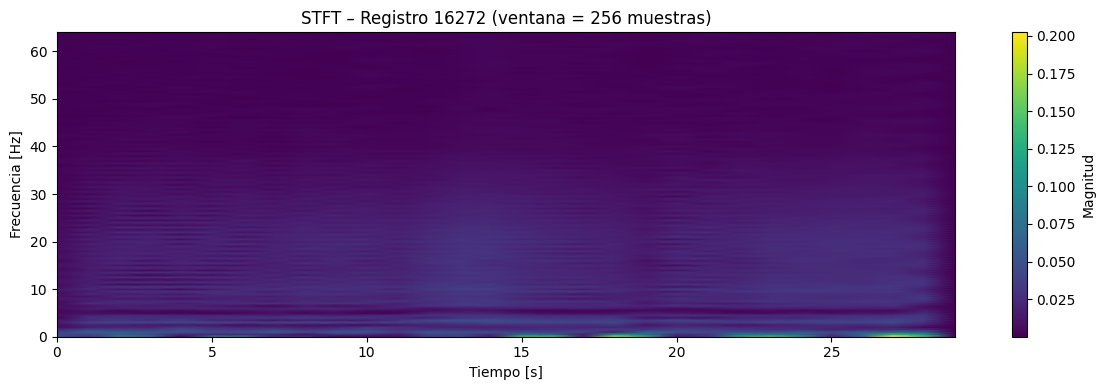

In [31]:
# ============================================
# EJERCICIO 2.2 - COMPARACIÓN DEL TAMAÑO DE VENTANA
# ============================================

record_name = "16272"

x = fft_data[record_name]["signal_ac"]
fs = sampling_rates[record_name]

windows = [32, 128, 256]

for nperseg in windows:

    f, t, zxx = calculate_stft(x, fs, nperseg)

    plt.figure(figsize=(12, 4))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"STFT – Registro {record_name} (ventana = {nperseg} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()

# 15. Preguntas conceptuales

### 1. ¿Qué es PhysioNet?

PhysioNet es una plataforma que contiene bases de datos de señales biomédicas, como señales ECG, que pueden utilizarse para su análisis y estudio.

### 2. ¿Qué información proporciona `record.p_signal`?

`record.p_signal` contiene los valores de la señal registrados en forma de muestras. En este caso, contiene los valores de la señal ECG que se analiza.

### 3. ¿Qué representa la frecuencia de muestreo `fs`?

`fs` indica cuántas muestras de la señal se toman por segundo. Por ejemplo, `fs = 128 Hz` significa que se toman 128 muestras cada segundo.

### 4. ¿Qué representa la componente DC de una señal?

La componente DC representa el valor promedio o desplazamiento de la señal respecto a cero.

### 5. ¿Por qué se resta la media antes de analizar el espectro AC?

Se resta la media para eliminar la componente DC y poder analizar mejor las variaciones de la señal o componentes AC.

### 6. ¿Qué información proporciona la FFT?

La FFT permite conocer qué frecuencias están presentes en una señal y cuál es la magnitud de cada una.

### 7. ¿Qué información adicional proporciona la STFT?

La STFT permite observar cómo cambian las frecuencias de la señal a lo largo del tiempo, indicando en qué momentos aparecen determinadas frecuencias.

### 8. ¿Qué relación existe entre `fs`, número de muestras y duración?

La duración se obtiene dividiendo el número de muestras entre la frecuencia de muestreo:

**Duración = número de muestras / `fs`**

Por ejemplo, 3600 muestras con `fs = 128 Hz` representan aproximadamente 28.12 segundos.

### 9. ¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?

Al aumentar el tamaño de ventana se obtiene mayor detalle en frecuencia, pero se pierde precisión para identificar exactamente cuándo ocurren los eventos.

### 10. ¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?

Porque la representación temporal permite observar cómo cambia la señal con el tiempo, pero no permite identificar fácilmente todas las frecuencias que la componen. Por eso es útil complementar el análisis temporal con la FFT y la STFT.

# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
